## SDR-Logger: RTL-SDR-Samples aufnehmen und wiedergeben

Dieses Notebook baut auf `SDR-radiolink.ipynb` auf und stellt Funktionen bereit, um:

- **LIVE**-Samples mit dem RTL-SDR einzulesen (mit vorgegebenen Settings),
- diese Samples in eine **Datei zu speichern** (inkl. Metadaten wie Frequenz, Sample-Rate, Gain, Zeitstempel),
- gespeicherte Samples später wieder zu **laden und auszuwerten** (**REPLAY**).

So können Studierende Live-Signale im Labor aufzeichnen und außerhalb der Laborübung erneut einlesen und analysieren.

### Windows: Treiber-Pfad setzen (vor dem Import)

Falls du unter Windows arbeitest: Zelle ausführen, damit **librtlsdr.dll** gefunden wird.

In [6]:
import os
from pathlib import Path

_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: rtl-sdr-driver (librtlsdr.dll) nicht gefunden.")

RTL-SDR Treiber gefunden: C:\Users\kissb\_Git\KT-course\rtl-sdr-driver


### Parameter: SDR-Einstellungen und Speicherpfad

Diese Parameter werden für **Aufnahme (Record)** und **Wiedergabe (Replay)** verwendet.

In [7]:
import numpy as np
import json
import datetime as dt

# SDR-Parameter (an SDR-radiolink angelehnt)
CENTER_FREQ_HZ = 433.9e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20.0
NUM_SAMPLES = 4096  # Samples pro Block
NUM_BLOCKS = 32     # Anzahl Blöcke für eine Aufnahme (anpassbar)

# Ordner für Log-Dateien
LOG_DIR = Path.cwd() / "sdr_logs"
LOG_DIR.mkdir(exist_ok=True)
print("Log-Verzeichnis:", LOG_DIR)

Log-Verzeichnis: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\sdr_logs


### Funktionen: RECORD (Samples aufzeichnen) und REPLAY (Samples von Datei laden)

Format der Log-Datei:

- **.npz** (NumPy-Archiv) mit
  - `samples`: komplexe IQ-Samples (`complex64`, wie vom RTL-SDR geliefert),
  - `meta`: JSON-String mit Metadaten (`center_freq_hz`, `sample_rate_hz`, `gain_db`, `num_samples`, `num_blocks`, `timestamp`).

So können dieselben Samples später mit identischen Parametern wieder eingelesen und analysiert werden.

In [8]:
from rtlsdr import RtlSdr

def record_sdr(filename: str,
               center_freq_hz: float = CENTER_FREQ_HZ,
               sample_rate_hz: float = SAMPLE_RATE_HZ,
               gain_db: float = GAIN_DB,
               num_samples: int = NUM_SAMPLES,
               num_blocks: int = NUM_BLOCKS) -> Path:
    """
    RTL-SDR-Samples aufzeichnen und als .npz-Datei speichern.
    - filename: Basisname (ohne Pfad); wird in LOG_DIR abgelegt.
    - Rückgabe: Pfad zur gespeicherten Datei.
    """
    LOG_DIR.mkdir(exist_ok=True)
    out_path = LOG_DIR / (filename if filename.endswith('.npz') else filename + '.npz')

    sdr = RtlSdr()
    sdr.sample_rate = sample_rate_hz
    sdr.center_freq = center_freq_hz
    sdr.gain = gain_db

    # Optional: erstes Paket verwerfen (oft noch nicht stabil)
    _ = sdr.read_samples(num_samples)

    blocks = []
    for i in range(num_blocks):
        samples = sdr.read_samples(num_samples)
        blocks.append(samples.astype(np.complex64))
    sdr.close()

    all_samples = np.concatenate(blocks) if blocks else np.array([], dtype=np.complex64)

    meta = {
        'center_freq_hz': float(center_freq_hz),
        'sample_rate_hz': float(sample_rate_hz),
        'gain_db': float(gain_db),
        'num_samples': int(num_samples),
        'num_blocks': int(num_blocks),
        'timestamp': dt.datetime.utcnow().isoformat() + 'Z',
    }

    np.savez_compressed(out_path, samples=all_samples, meta=json.dumps(meta))
    print(f"Aufnahme gespeichert: {out_path} ({all_samples.size} Samples)")
    return out_path

def replay_sdr(path: str | Path):
    """
    Samples und Metadaten aus einer .npz-Datei laden.
    Rückgabe: (samples: np.ndarray[complex64], meta: dict)
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    data = np.load(path, allow_pickle=True)
    samples = data['samples'].astype(np.complex64)
    meta_json = data.get('meta')
    if meta_json is None:
        meta = {}
    else:
        meta_str = str(meta_json) if isinstance(meta_json, str) else meta_json.item()
        meta = json.loads(meta_str)
    print(f"Datei geladen: {path} ({samples.size} Samples)")
    print(f"Metadaten: {meta}")
    return samples, meta


### Beispiel: einfache Aufnahme und Wiedergabe

Die folgenden Zellen zeigen, wie man eine kurze Aufnahme durchführt und anschließend wieder einliest. Die weitere **Auswertung** (z. B. FFT, Spektrumsplot) kann analog zu anderen Notebooks erfolgen (z. B. `np.fft.fft` auf den geladenen Samples).

In [9]:
# Beispiel: kurze Aufnahme (Record)
# Achtung: Diese Zelle startet den RTL-SDR und liest NUM_BLOCKS * NUM_SAMPLES Samples ein.
# Dateiname kann angepasst werden.

# out_file = record_sdr('sdr_record_433mhz')
# samples, meta = replay_sdr(out_file)
# print(samples[:10])  # erste 10 Samples zur Kontrolle

print("Beispiel: record_sdr('sdr_record_433mhz') und replay_sdr(...) in dieser Zelle aktivieren.")

Beispiel: record_sdr('sdr_record_433mhz') und replay_sdr(...) in dieser Zelle aktivieren.


### Labor-Check: Record → Replay → Betragsspektrum

Diese Zelle führt nacheinander **Record**, **Replay** und eine **Spektralanalyse** aus und plottet das Betragsspektrum. So könnt ihr prüfen, ob die Aufzeichnung sinnvolle Spektren liefert (z. B. Träger bei 433,9 MHz sichtbar).

Aufnahme gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\sdr_logs\sdr_lab_check.npz (131072 Samples)
Datei geladen: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\sdr_logs\sdr_lab_check.npz (131072 Samples)
Metadaten: {'center_freq_hz': 433900000.0, 'sample_rate_hz': 2048000.0, 'gain_db': 20.0, 'num_samples': 4096, 'num_blocks': 32, 'timestamp': '2026-03-18T12:49:56.321453Z'}


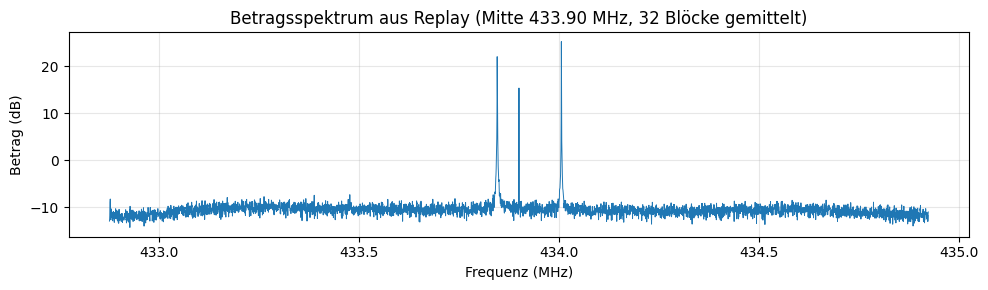

In [10]:
import matplotlib.pyplot as plt

# 1) Record: Live-Samples aufzeichnen
out_file = record_sdr('sdr_lab_check')

# 2) Replay: Samples und Metadaten laden
samples, meta = replay_sdr(out_file)

# 3) Betragsspektrum: aus replayed Daten (pro Block FFT, dann mitteln, wie in SDR-radiolink)
fs = meta.get('sample_rate_hz', SAMPLE_RATE_HZ)
N = meta.get('num_samples', NUM_SAMPLES)
n_blocks = meta.get('num_blocks', NUM_BLOCKS)
center_hz = meta.get('center_freq_hz', CENTER_FREQ_HZ)

# In Blöcke der Länge N aufteilen (evtl. Rest verwerfen)
n_full = (len(samples) // N) * N
blocks = samples[:n_full].reshape(-1, N)

magnitude_sum = np.zeros(N, dtype=np.float64)
for blk in blocks:
    magnitude_sum += np.abs(np.fft.fft(blk))
magnitude_avg = magnitude_sum / len(blocks)

freq = np.fft.fftshift(np.fft.fftfreq(N, 1 / fs))
magnitude_shifted = np.fft.fftshift(magnitude_avg)
freq_mhz = (center_hz + freq) / 1e6   # Frequenzachse in MHz (absolut)
magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-20)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(freq_mhz, magnitude_dB, color='C0', linewidth=0.7)
ax.set_xlabel('Frequenz (MHz)')
ax.set_ylabel('Betrag (dB)')
ax.set_title(f'Betragsspektrum aus Replay (Mitte {center_hz/1e6:.2f} MHz, {len(blocks)} Blöcke gemittelt)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()